<a href="https://colab.research.google.com/github/Jephia-Robart/DBA-Data-Analysis/blob/main/DBA_Dataset_Cleaning_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install necessary libraries
!pip install pymongo dnspython

# 2. Clone the repository
# We use a 'try' block or 'rm' to ensure it doesn't fail if the folder exists
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

# 3. Load the data directly from the cloned GitHub folder
github_path = '/content/DBA-Data-Analysis/app_events.csv'
app_events = pd.read_csv(github_path)

# 4. Data Cleaning
# Clean 'zone_context'
app_events['zone_context'] = app_events['zone_context'].str.strip().str.upper().replace('CTR', 'CENTRAL')

# Missing Order id's
app_events['order_id'] = app_events['order_id'].fillna('BROWSE_SESSION')

# 5. Save the updated file locally in Colab
# This creates a new file called 'app_events_cleaned.csv' in your Colab files
app_events.to_csv('app_events_cleaned.csv', index=False)

# 6. Verification
print("✅ app_events.csv has been cleaned!")
print("Unique Zones found:", app_events['zone_context'].unique())
print("\nFirst 5 rows of cleaned data:")
display(app_events.head(5))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 24.3 MB/s eta 0:00:00
Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 96.64 KiB | 5.09 MiB/s, done.
Resolving deltas: 100% (1/1), done.
✅ app_events.csv has been cleaned!
Unique Zones found: ['NORTH' 'SOUTH' 'AIRPORT' 'CENTRAL' 'WEST' 'RIVERSIDE' 'EAST']

First 5 rows of cleaned data:


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,BROWSE_SESSION,09/08/2024 03:25,eta_refresh,S19847,Android,NORTH,301,1
1,AE00002,C0595,O00950,13/02/2024 22:29,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,11/08/2025 09:29,chat_opened,S99516,iOS,AIRPORT,1118,1
3,AE00004,C0407,O00756,23/08/2025 17:38,eta_refresh,S41236,iOS,CENTRAL,442,1
4,AE00005,C0506,BROWSE_SESSION,29/05/2024 10:33,search_route,S12030,iOS,NORTH,60,1


In [ ]:
# 1. Clone the repository
# Ensures we have the fresh version of the files
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

# Define the path from the cloned GitHub folder
path_complaints = '/content/DBA-Data-Analysis/complaints.csv'

# Load the data
complaints = pd.read_csv(path_complaints)

# Standardize 'status' to Uppercase for consistent filtering
if 'status' in complaints.columns:
    complaints['status'] = complaints['status'].str.strip().str.upper()

# Set Resolution Days and Compensation to 0 for specific statuses
active_statuses = ['OPEN', 'ESCALATED', 'AWAITING CUSTOMER']

if 'resolution_days' in complaints.columns:
    complaints.loc[complaints['status'].isin(active_statuses), 'resolution_days'] = 0

if 'amount_compensation' in complaints.columns:
    complaints.loc[complaints['status'].isin(active_statuses), 'amount_compensation'] = 0

# Standardize 'created_at' (dd/mm/yyyy hh:mm - NO SECONDS)
if 'created_at' in complaints.columns:
    complaints['created_at'] = pd.to_datetime(complaints['created_at'], errors='coerce').dt.strftime('%d/%m/%Y %H:%M')

# Clean remaining Categorical Columns
categorical_cols = ['complaint_category', 'priority']
for col in categorical_cols:
    if col in complaints.columns:
        complaints[col] = complaints[col].str.strip().str.upper()

# Handle Missing IDs
if 'order_id' in complaints.columns:
    complaints['order_id'] = complaints['order_id'].fillna('GENERAL_ENQUIRY')
if 'customer_id' in complaints.columns:
    complaints['customer_id'] = complaints['customer_id'].fillna('ANONYMOUS')

# OVERWRITE the file in Google Drive
complaints.to_csv(path_complaints, index=False)

# Verification
print("✅ complaints.csv updated successfully with 'created_at' format!")
display(complaints.head(10))

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 1.02 MiB/s, done.
✅ complaints.csv updated successfully with 'created_at' format!


/tmp/ipykernel_20967/2873595178.py:31: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  complaints['created_at'] = pd.to_datetime(complaints['created_at'], errors='coerce').dt.strftime('%d/%m/%Y %H:%M')


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,30/03/2025 02:36,OPEN,0,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,07/11/2024 10:05,OPEN,0,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,02/01/2024 15:47,OPEN,0,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,14/01/2025 13:07,AWAITINGCUSTOMER,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,31/08/2024 05:56,RESOLVED,1,16.18
5,CP0006,C0096,O00147,Delay,App,Medium,22/07/2024 07:43,RESOLVED,9,18.51
6,CP0007,C0597,O00981,MissedPickup,App,Medium,15/01/2025 21:57,ESCALATED,0,14.14
7,CP0008,C0309,O00902,AppIssue,Email,High,26/09/2024 19:41,RESOLVED,18,NaN
8,CP0009,C0340,O00011,Delay,App,Low,16/08/2025 04:19,RESOLVED,4,26.35
9,CP0010,C0486,O00417,DriverBehaviour,Phone,Medium,13/01/2025 15:33,OPEN,0,6.32


In [ ]:
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

path_customers = '/content/DBA-Data-Analysis/customers.csv'
customers = pd.read_csv(path_customers)

# Add 'NaN' to empty preferred_channel slots
customers['preferred_channel'] = customers['preferred_channel'].fillna('NaN')

customers['app_engagement_score'] = pd.to_numeric(customers['app_engagement_score'], errors='coerce')

# Numbers were changed to decimals.
customers.to_csv(path_customers, index=False, float_format='%.1f')

display(customers.head())

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 1001.00 KiB/s, done.


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,NORTH,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,EAST,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,RIVERSIDE,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [ ]:
print("No data inconsistencies in data_dictionary.csv")

No data inconsistencies in data_dictionary.csv


In [ ]:
print("No data inconsistencies in deliveries.csv")

No data inconsistencies in deliveries.csv


In [ ]:
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

path_deliveries = '/content/DBA-Data-Analysis/deliveries.csv'
deliveries = pd.read_csv(path_deliveries)

# Handle Logical Consistency
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'], dayfirst=True, errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], dayfirst=True, errors='coerce')

# Swap values if completion is before dispatch
mask_swap = deliveries['delivery_completed_at'] < deliveries['dispatch_time']
deliveries.loc[mask_swap, ['dispatch_time', 'delivery_completed_at']] = \
    deliveries.loc[mask_swap, ['delivery_completed_at', 'dispatch_time']].values

# Calculate Duration
deliveries['duration_minutes'] = (deliveries['delivery_completed_at'] - deliveries['dispatch_time']).dt.total_seconds() / 60
deliveries.loc[deliveries['delivery_completed_at'].isna(), 'delivery_status'] = 'Failed'
has_time = deliveries['delivery_completed_at'].notna()
is_same_day = deliveries['dispatch_time'].dt.date == deliveries['delivery_completed_at'].dt.date
is_more_than_one_day = deliveries['delivery_completed_at'].dt.date > deliveries['dispatch_time'].dt.date

# Apply 'OnTime' for same day
deliveries.loc[has_time & is_same_day, 'delivery_status'] = 'OnTime'

# Apply 'Delayed' for 1+ days difference
deliveries.loc[has_time & is_more_than_one_day, 'delivery_status'] = 'Delayed'

# Standardize Timestamps back to Strings
deliveries['dispatch_time'] = deliveries['dispatch_time'].dt.strftime('%d/%m/%Y %H:%M')
deliveries['delivery_completed_at'] = deliveries['delivery_completed_at'].dt.strftime('%d/%m/%Y %H:%M')

# Fill empty labels for final file
deliveries['delivery_completed_at'] = deliveries['delivery_completed_at'].fillna("Not provided")
deliveries['duration_minutes'] = deliveries['duration_minutes'].astype(object).fillna("Not enough data")

# Data Type Optimization
deliveries['customer_rating_post_delivery'] = pd.to_numeric(deliveries['customer_rating_post_delivery'], errors='coerce').fillna(0.0)
deliveries['route_distance_km'] = pd.to_numeric(deliveries['route_distance_km'], errors='coerce').astype(float)
deliveries['fuel_or_charge_cost'] = pd.to_numeric(deliveries['fuel_or_charge_cost'], errors='coerce').astype(float)

# Save
deliveries.to_csv(path_deliveries, index=False)

# Verification
print("✅ Delivery Status logic updated!")
print(f"Summary of statuses:\n{deliveries['delivery_status'].value_counts()}")
display(deliveries.head(15))


Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 1001.00 KiB/s, done.
✅ Delivery Status logic updated!
Summary of statuses:
delivery_status
OnTime     588
Delayed    343
Failed      19
Name: count, dtype: int64


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,duration_minutes
0,DL00001,O00938,D004,V056,H05,18/06/2024 10:57,19/06/2024 09:05,Delayed,17.26,1,0,3.07,12.05,1328.0
1,DL00002,O00004,D138,V007,H02,11/01/2025 17:39,11/01/2025 18:45,OnTime,10.34,1,0,5.00,13.41,66.0
2,DL00003,O00639,D006,V049,H02,02/06/2025 20:39,02/06/2025 21:45,OnTime,7.92,0,0,4.98,8.51,66.0
3,DL00004,O00313,D116,V055,H02,08/03/2024 23:31,09/03/2024 23:30,Delayed,16.42,0,0,4.18,13.62,1439.0
4,DL00005,O00844,D108,V034,H01,21/09/2025 11:43,21/09/2025 15:45,OnTime,14.52,1,0,4.18,9.22,242.0
5,DL00006,O00029,D037,V098,H03,11/09/2024 12:40,12/09/2024 17:11,Delayed,13.84,0,0,1.57,9.58,1711.0
6,DL00007,O00097,D151,V037,H07,09/01/2024 13:41,10/01/2024 23:39,Delayed,32.72,0,0,4.64,17.70,2038.0
7,DL00008,O00207,D082,V066,H03,22/08/2024 21:34,22/08/2024 23:22,OnTime,7.16,1,0,3.76,11.66,108.0
8,DL00009,O00297,D088,V029,H05,12/04/2024 21:33,13/04/2024 01:18,Delayed,40.23,1,0,3.70,15.78,225.0
9,DL00010,O00836,D058,V057,H08,22/09/2025 19:09,23/09/2025 01:15,Delayed,9.85,1,0,3.20,9.31,366.0


In [ ]:
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

path_drivers = '/content/DBA-Data-Analysis/drivers.csv'
drivers = pd.read_csv(path_drivers)

# 2. Clean 'base_zone': Strip, Uppercase, and Fix 'CTR'
drivers['base_zone'] = drivers['base_zone'].str.strip().str.upper()
drivers['base_zone'] = drivers['base_zone'].replace('CTR', 'CENTRAL')

# 3. Standardize other categorical columns to Uppercase
# This ensures consistency across the whole portfolio
drivers['employment_type'] = drivers['employment_type'].str.capitalize()
drivers['shift_preference'] = drivers['shift_preference'].str.capitalize()

# 4. Handle Missing Values for MongoDB
# We fill scores with 0.0 to ensure MongoDB recognizes them as Doubles (Decimals)
drivers['training_score'] = drivers['training_score'].fillna(0.0)
drivers['driver_rating'] = drivers['driver_rating'].fillna(0.0)

# 5. Overwrite the file in Drive
drivers.to_csv(path_drivers, index=False)

# 6. Verification
print("✅ drivers.csv updated successfully!")
print("Unique Zones:", drivers['base_zone'].unique())

display(drivers.head(30))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ drivers.csv updated successfully!
Unique Zones: ['AIRPORT' 'CENTRAL' 'NORTH' 'SOUTH' 'WEST' 'EAST' 'RIVERSIDE']


,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
0,D001,AIRPORT,Fulltime,8,67.8,3.54,Morning,1
1,D002,CENTRAL,Fulltime,4,42.4,3.94,Evening,1
2,D003,AIRPORT,Fulltime,11,96.5,5.00,Evening,1
3,D004,AIRPORT,Parttime,13,88.9,4.75,Morning,1
4,D005,NORTH,Fulltime,3,69.7,4.14,Morning,1
5,D006,CENTRAL,Fulltime,8,78.8,4.38,Flexible,1
6,D007,NORTH,Fulltime,4,92.6,3.94,Evening,1
7,D008,SOUTH,Fulltime,9,84.1,3.88,Morning,1
8,D009,AIRPORT,Fulltime,15,63.4,3.80,Night,1
9,D010,WEST,Fulltime,8,70.0,3.95,Evening,1


In [ ]:
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

path_hubs = '/content/DBA-Data-Analysis/hubs.csv'
hubs = pd.read_csv(path_hubs)

# 5. Zone to Uppercase
hubs['zone'] = hubs['zone'].str.strip().str.upper()

# 6. OVERWRITE the file in Google Drive
hubs.to_csv(path_hubs, index=False)

# 7. Verification
print("✅ hubs.csv updated in Drive!")
display(hubs.head(5))

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 961.00 KiB/s, done.
✅ hubs.csv updated in Drive!


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,NORTH,Dispatch,82
1,H02,South Link,SOUTH,Dispatch,78
2,H03,East Dock,EAST,Warehouse,74
3,H04,West Gate,WEST,Dispatch,69
4,H05,Central Core,CENTRAL,Control,88


In [ ]:
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

path_incidents = '/content/DBA-Data-Analysis/incidents.csv'
incidents = pd.read_csv(path_incidents)

# 1. Logical Reset (Updated to match the new casing)
active_statuses = ['Open', 'Escalated', 'Pending_Vendor']
incidents.loc[incidents['resolution_status'].isin(active_statuses), 'resolved_hours'] = 0.0

# 2. Final Data Typing
incidents['resolved_hours'] = incidents['resolved_hours'].fillna(0.0).astype(float)
display(incidents.head(15))

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 1022.00 KiB/s, done.


,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,0.0
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,0.0
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,0.0
3,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
4,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,0.0
5,I0006,DL00634,CustomerNoShow,2025-08-08 21:26:00,High,PendingVendor,19.9
6,I0007,DL00495,AppSyncError,2024-05-23 02:29:00,Low,PendingVendor,4.8
7,I0008,DL00602,RouteDeviation,2024-08-17 01:27:00,Medium,Closed,12.1
8,I0009,DL00636,CustomerNoShow,2024-08-24 22:28:00,Medium,Closed,15.8
9,I0010,DL00052,CustomerNoShow,2025-05-06 14:17:00,Medium,Closed,9.4


In [ ]:
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

path_orders = '/content/DBA-Data-Analysis/orders.csv'
orders = pd.read_csv(path_orders)

# 3. Clean 'pickup_zone' and 'dropoff_zone'
# We strip spaces, uppercase everything, and replace 'CTR' with 'CENTRAL'
zone_cols = ['pickup_zone', 'dropoff_zone']
for col in zone_cols:
    orders[col] = orders[col].str.strip().str.upper().replace('CTR', 'CENTRAL')

# 4. Standardize other categorical columns to UPPERCASE
# This fixes the "other inconsistencies" where mixed casing (App vs app) exists
cat_cols = ['service_type', 'priority_level', 'booking_channel']
for col in cat_cols:
    orders[col] = orders[col].str.strip().str.capitalize()

# 5. Handle missing numerical data for MongoDB compatibility
# Ensures order_value is a float and replaces NaNs with 0.0
orders['order_value'] = pd.to_numeric(orders['order_value'], errors='coerce').fillna(0.0)

# 6. Remove any duplicate orders to maintain data integrity
orders.drop_duplicates(inplace=True)

# 7. OVERWRITE the file (or save as V2)
orders.to_csv('orders.csv', index=False)

# 8. Verification
print("✅ orders.csv cleaning complete!")
print(f"Unique Pickup Zones: {orders['pickup_zone'].unique()}")
print(f"Unique Service Types: {orders['service_type'].unique()}")
display(orders.head(15))

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 17 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 103.23 KiB | 7.37 MiB/s, done.
Resolving deltas: 100% (3/3), done.
✅ orders.csv cleaning complete!
Unique Pickup Zones: ['AIRPORT' 'NORTH' 'WEST' 'RIVERSIDE' 'CENTRAL' 'SOUTH' 'EAST']
Unique Service Types: ['Passenger' 'Parcel' 'Retail' 'Business' 'Medical']


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,AIRPORT,SOUTH,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,NORTH,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,WEST,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RIVERSIDE,NORTH,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,RIVERSIDE,SOUTH,Low,125.58,Phone,0
5,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,EAST,High,151.44,Web,1
6,O00007,C0001,Business,2024-05-05 21:32:00,2,CENTRAL,AIRPORT,Low,76.12,App,0
7,O00008,C0157,Parcel,2024-04-03 17:54:00,4,RIVERSIDE,RIVERSIDE,Medium,35.06,Phone,0
8,O00009,C0141,Retail,2024-10-03 23:49:00,12,NORTH,EAST,Critical,78.93,App,0
9,O00010,C0171,Retail,2025-01-29 00:42:00,6,SOUTH,NORTH,Low,34.55,Phone,0


In [ ]:
# ============================================
# CREATE ORDERS.CSV FROM SCRATCH AND UPLOAD TO GITHUB
# ============================================

# 1. Clone the repository (will be empty for orders.csv)
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

# 2. FIRST, check if you have the orders data in any other form
# Look for orders_cleaned.csv that you saved earlier
if os.path.exists('/content/orders_cleaned.csv'):
    print("Found orders_cleaned.csv in current directory!")
    orders = pd.read_csv('/content/orders_cleaned.csv')
elif os.path.exists('/content/DBA-Data-Analysis/orders_cleaned.csv'):
    print("Found orders_cleaned.csv in GitHub folder!")
    orders = pd.read_csv('/content/DBA-Data-Analysis/orders_cleaned.csv')
else:
    # If no cleaned version exists, we need to get the original from somewhere
    print("No cleaned orders found. Looking for original orders.csv from your local...")

    # Check if you have the original file in any location
    possible_paths = [
        '/content/orders.csv',
        '/content/DBA-Data-Analysis/orders.csv.bak',
        '/content/sample_data/orders.csv'
    ]

    found = False
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Found orders at: {path}")
            orders = pd.read_csv(path)
            found = True
            break

    if not found:
        print("❌ No orders file found. Please upload orders.csv manually to Colab.")
        print("   Click the folder icon → Upload → select your orders.csv file")
        # Wait for user to upload
        input("Press Enter after you have uploaded orders.csv...")
        orders = pd.read_csv('/content/orders.csv')

# 3. Clean the data
print("\n--- CLEANING DATA ---")

# Clean 'pickup_zone' and 'dropoff_zone'
zone_cols = ['pickup_zone', 'dropoff_zone']
for col in zone_cols:
    if col in orders.columns:
        orders[col] = orders[col].astype(str).str.strip().str.upper().replace('CTR', 'CENTRAL')

# Standardize other categorical columns
cat_cols = ['service_type', 'priority_level', 'booking_channel']
for col in cat_cols:
    if col in orders.columns:
        orders[col] = orders[col].astype(str).str.strip().str.capitalize()

# Handle missing numerical data
if 'order_value' in orders.columns:
    orders['order_value'] = pd.to_numeric(orders['order_value'], errors='coerce').fillna(0.0)

# Remove duplicates
orders.drop_duplicates(inplace=True)

print(f"✅ Cleaned orders DataFrame has {len(orders)} rows")

# 4. Save to the GitHub folder
orders.to_csv('/content/DBA-Data-Analysis/orders.csv', index=False)
print("✅ Saved to /content/DBA-Data-Analysis/orders.csv")

# 5. Push to GitHub
print("\n--- PUSHING TO GITHUB ---")

# Configure git
!git config --global user.email "jephia4robart@gmail.com"  # Replace with your email
!git config --global user.name "Jephia-Robart"

# Navigate to repo
os.chdir('/content/DBA-Data-Analysis')

# Add, commit, push
!git add orders.csv
!git commit -m "Add cleaned orders.csv with uppercase zones"

# Try to push (will ask for credentials)
!git push origin main

os.chdir('/content')

print("\n✅ Done! Check your GitHub repository.")

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 96.64 KiB | 4.83 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Found orders_cleaned.csv in current directory!

--- CLEANING DATA ---
✅ Cleaned orders DataFrame has 1250 rows
✅ Saved to /content/DBA-Data-Analysis/orders.csv

--- PUSHING TO GITHUB ---
[main 3a143e7] Add cleaned orders.csv with uppercase zones
 1 file changed, 1251 insertions(+)
 create mode 100644 orders.csv
fatal: could not read Username for 'https://github.com': No such device or address

✅ Done! Check your GitHub repository.


In [ ]:
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

import pandas as pd
import os

path_vehicles = '/content/DBA-Data-Analysis/vehicles.csv'
vehicles = pd.read_csv(path_vehicles)

# Fix 'assigned_zone'
vehicles['assigned_zone'] = vehicles['assigned_zone'].str.strip().str.upper().replace('CTR', 'CENTRAL')

# Save
vehicles.to_csv(path_vehicles, index=False)

# Verification
print("✅ Column formatting fixed!")
display(vehicles.head())

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 961.00 KiB/s, done.
✅ Column formatting fixed!


,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,NORTH,2024-12-28 23:48:00,71.8,56928,Active,V2.2
1,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,V2.2
2,V003,CargoVan,NORTH,2025-11-24 23:59:00,91.7,219359,Active,V2.1
3,V004,Hybrid,RIVERSIDE,2024-06-07 13:21:00,0.0,36310,Active,V2.2
4,V005,CargoVan,WEST,2025-11-15 11:08:00,58.6,146638,Active,V2.2


Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 5.64 MiB/s, done.


/tmp/ipykernel_14581/103693058.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


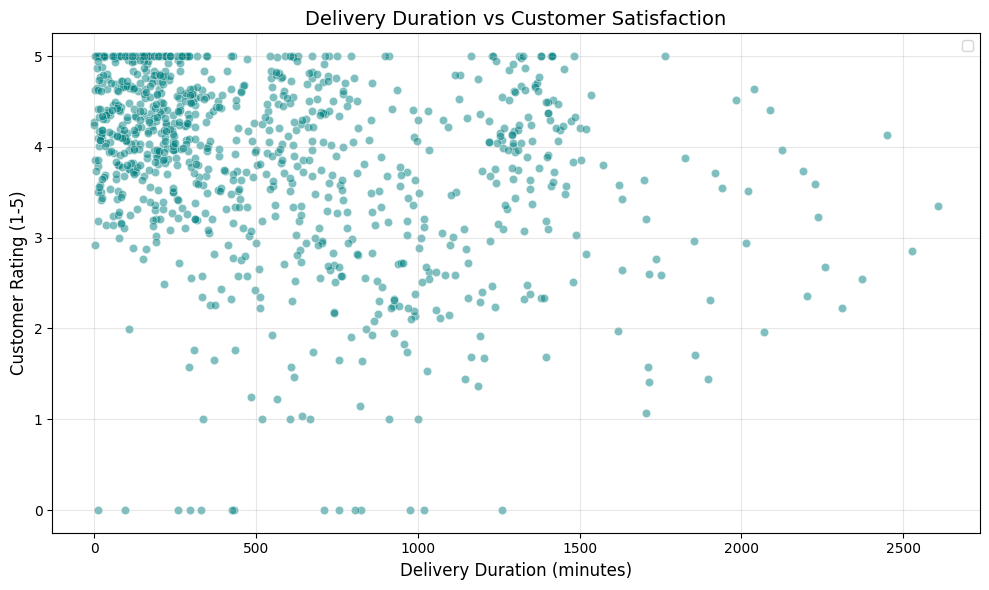


📊 Correlation: -0.272
Interpretation: Negative value = longer deliveries receive lower ratings


In [ ]:
# ============================================
# GRAPH 1: Does longer delivery = lower rating?
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Clone repository
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

# Load data
deliveries = pd.read_csv('DBA-Data-Analysis/deliveries.csv')
orders = pd.read_csv('DBA-Data-Analysis/orders.csv')

# Clean data
deliveries['duration_minutes'] = pd.to_numeric(deliveries['duration_minutes'], errors='coerce')

# Merge
merged = deliveries.merge(orders, on='order_id', how='inner')
merged = merged.dropna(subset=['duration_minutes', 'customer_rating_post_delivery'])

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(merged['duration_minutes'], merged['customer_rating_post_delivery'],
            alpha=0.5, color='teal', edgecolors='white', linewidth=0.5)

plt.xlabel('Delivery Duration (minutes)', fontsize=12)
plt.ylabel('Customer Rating (1-5)', fontsize=12)
plt.title('Delivery Duration vs Customer Satisfaction', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print correlation
corr = merged['duration_minutes'].corr(merged['customer_rating_post_delivery'])
print(f"\n📊 Correlation: {corr:.3f}")
print("Interpretation: Negative value = longer deliveries receive lower ratings")

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 95.82 KiB | 4.56 MiB/s, done.


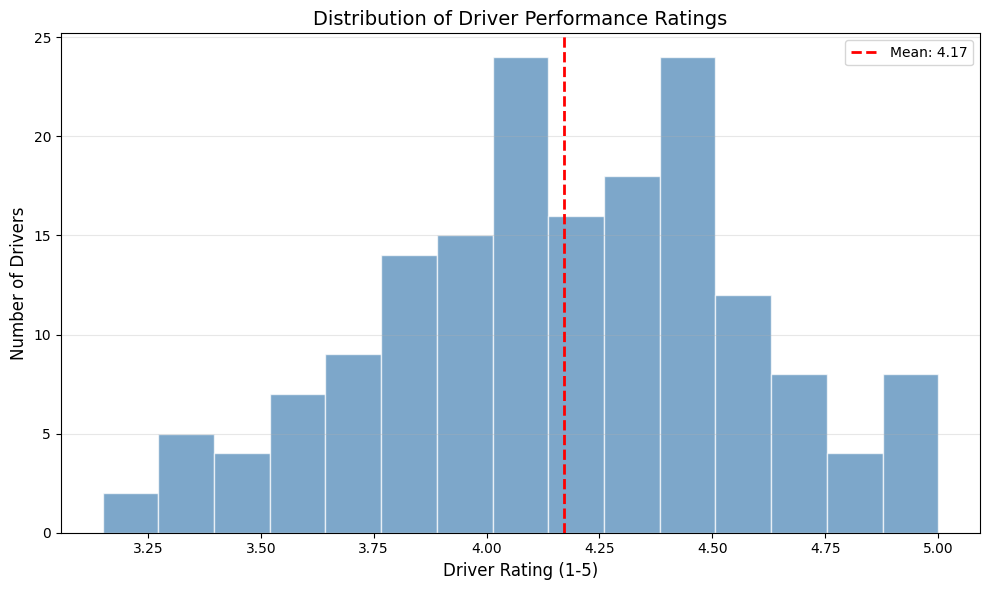


📊 Summary:
   Mean rating: 4.17
   Median rating: 4.17
   Lowest rating: 3.15
   Highest rating: 5.00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Clone the repository to ensure files are available
!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git

# Define the path to the drivers.csv file
path_drivers = '/content/DBA-Data-Analysis/drivers.csv'

# Load data using pandas directly from the CSV file
drivers_ratings = pd.read_csv(path_drivers)

# Filter out drivers with NaN ratings, as the original query did
drivers_ratings = drivers_ratings[drivers_ratings['driver_rating'].notna()]

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(drivers_ratings['driver_rating'], bins=15, color='steelblue',
         edgecolor='white', alpha=0.7)

mean_rating = drivers_ratings['driver_rating'].mean()
plt.axvline(mean_rating, color='red', linestyle='dashed', linewidth=2,
            label=f'Mean: {mean_rating:.2f}')

plt.xlabel('Driver Rating (1-5)', fontsize=12)
plt.ylabel('Number of Drivers', fontsize=12)
plt.title('Distribution of Driver Performance Ratings', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n📊 Summary:")
print(f"   Mean rating: {mean_rating:.2f}")
print(f"   Median rating: {drivers_ratings['driver_rating'].median():.2f}")
print(f"   Lowest rating: {drivers_ratings['driver_rating'].min():.2f}")
print(f"   Highest rating: {drivers_ratings['driver_rating'].max():.2f}")

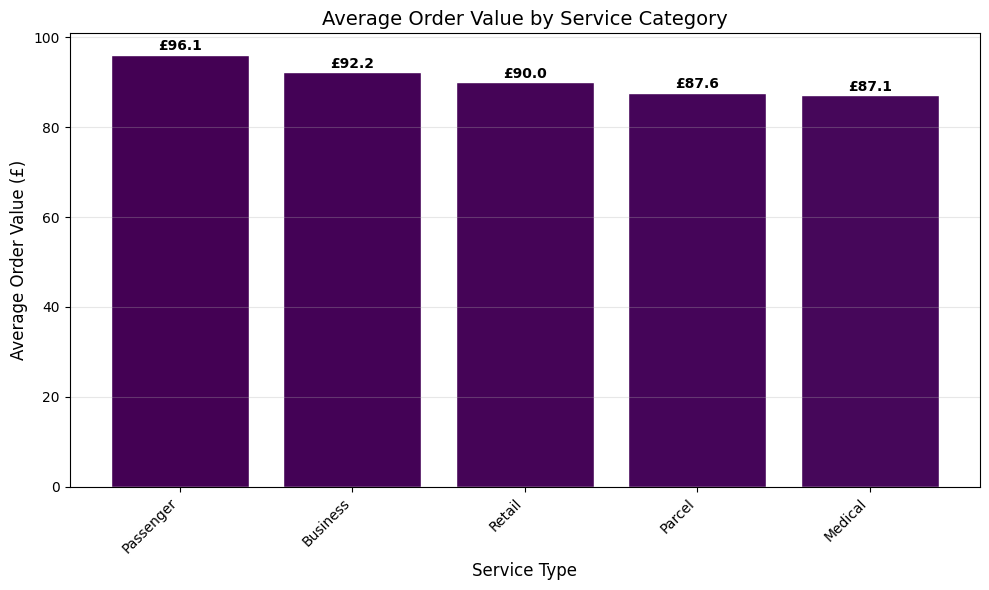


📊 Highest value service: Passenger ($96.07)
   Lowest value service: Medical ($87.14)


In [ ]:
# ============================================
# GRAPH 3: Which service type generates most revenue?
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load data
orders = pd.read_csv('DBA-Data-Analysis/orders.csv')

# Calculate average order value by service type
avg_value = orders.groupby('service_type')['order_value'].mean().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(range(len(avg_value)))
bars = plt.bar(avg_value.index, avg_value.values, color=colors, edgecolor='white')

# Add value labels on top of bars
for bar, value in zip(bars, avg_value.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'£{value:.1f}', ha='center', fontweight='bold')

plt.xlabel('Service Type', fontsize=12)
plt.ylabel('Average Order Value (£)', fontsize=12)
plt.title('Average Order Value by Service Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n📊 Highest value service: {avg_value.index[0]} (${avg_value.values[0]:.2f})")
print(f"   Lowest value service: {avg_value.index[-1]} (${avg_value.values[-1]:.2f})")

/tmp/ipykernel_14581/1751662437.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True)


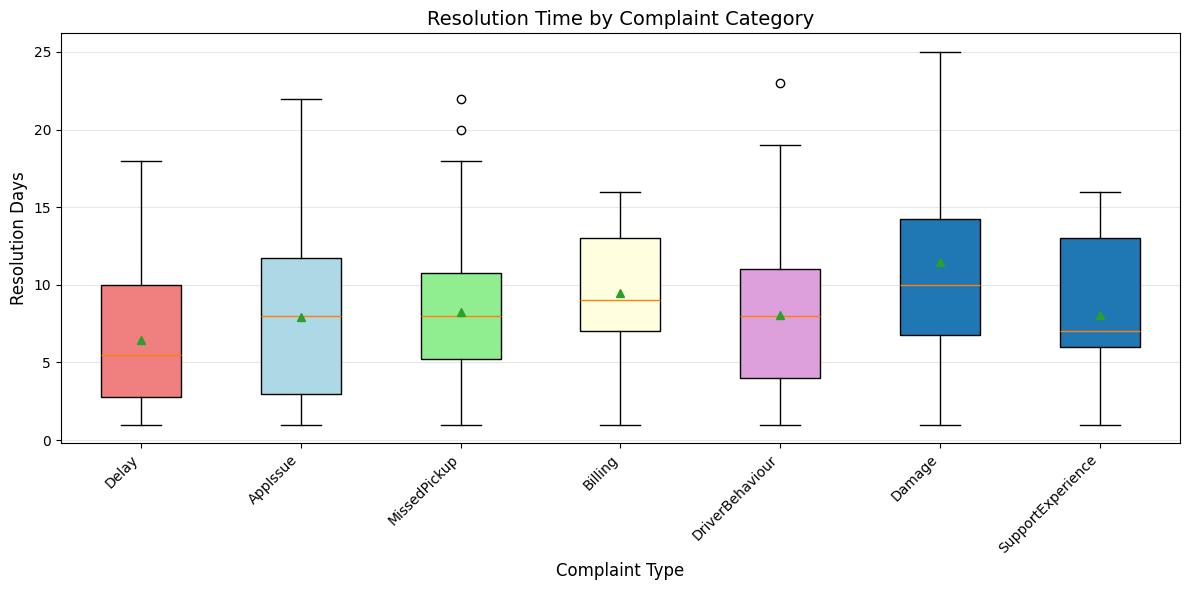


📊 Average resolution days by complaint type:
   Delay: 6.4 days (72 complaints)
   AppIssue: 7.9 days (42 complaints)
   MissedPickup: 8.3 days (46 complaints)
   Billing: 9.4 days (9 complaints)
   DriverBehaviour: 8.0 days (36 complaints)
   Damage: 11.5 days (8 complaints)
   SupportExperience: 8.1 days (13 complaints)


In [ ]:
# ============================================
# GRAPH 4: Which complaint types take longest to resolve?
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load data
complaints = pd.read_csv('DBA-Data-Analysis/complaints.csv')

# Filter only resolved complaints (days > 0)
resolved = complaints[complaints['resolution_days'] > 0]

# Create box plot
plt.figure(figsize=(12, 6))
box_data = [resolved[resolved['complaint_type'] == t]['resolution_days'].dropna()
            for t in resolved['complaint_type'].unique()]
labels = resolved['complaint_type'].unique()

bp = plt.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True)

# Color the boxes
colors = ['lightcoral', 'lightblue', 'lightgreen', 'lightyellow', 'plum']
for patch, color in zip(bp['boxes'], colors[:len(labels)]):
    patch.set_facecolor(color)

plt.xlabel('Complaint Type', fontsize=12)
plt.ylabel('Resolution Days', fontsize=12)
plt.title('Resolution Time by Complaint Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Calculate averages
print("\n📊 Average resolution days by complaint type:")
for t in resolved['complaint_type'].unique():
    avg = resolved[resolved['complaint_type'] == t]['resolution_days'].mean()
    count = len(resolved[resolved['complaint_type'] == t])
    print(f"   {t}: {avg:.1f} days ({count} complaints)")

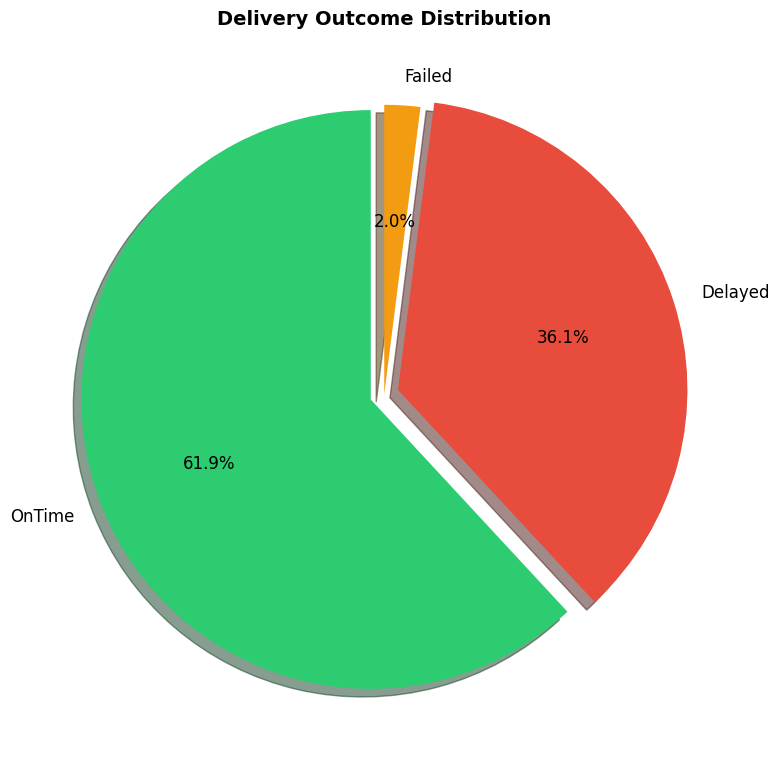


📊 Delivery breakdown:
   OnTime: 588 deliveries (61.9%)
   Delayed: 343 deliveries (36.1%)
   Failed: 19 deliveries (2.0%)


In [ ]:
# ============================================
# GRAPH 5: What percentage of deliveries succeed vs fail?
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load data
deliveries = pd.read_csv('DBA-Data-Analysis/deliveries.csv')

# Count by status
status_counts = deliveries['delivery_status'].value_counts()

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
explode = (0.05, 0.05, 0, 0)  # Slightly separate the first two slices

plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors[:len(status_counts)], explode=explode[:len(status_counts)],
        startangle=90, shadow=True, textprops={'fontsize': 12})
plt.title('Delivery Outcome Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Delivery breakdown:")
for status, count in status_counts.items():
    percentage = (count / status_counts.sum()) * 100
    print(f"   {status}: {count} deliveries ({percentage:.1f}%)")

**bold text**

In [ ]:
# ============================================
# CODE 6.1: Pandas Zone Performance Aggregation
# ============================================

import pandas as pd
import numpy as np

!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git
deliveries = pd.read_csv('DBA-Data-Analysis/deliveries.csv')

# handle 'Not enough data' strings
deliveries['duration_minutes'] = pd.to_numeric(deliveries['duration_minutes'], errors='coerce')

# Group by hub_id and aggregate multiple metrics
zone_performance = deliveries.groupby('hub_id').agg({
    'duration_minutes': ['mean', 'median', 'std'],
    'customer_rating_post_delivery': 'mean',
    'fuel_or_charge_cost': 'sum'
}).round(2)

# Rename columns for clarity
zone_performance.columns = ['Avg Duration (min)', 'Median Duration (min)',
                            'Std Dev Duration', 'Avg Customer Rating', 'Total Fuel Cost']

print("="*60)
print("ZONE PERFORMANCE AGGREGATION RESULTS")
print("="*60)
print(zone_performance)

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 17 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 103.23 KiB | 760.00 KiB/s, done.
Resolving deltas: 100% (3/3), done.
ZONE PERFORMANCE AGGREGATION RESULTS
        Avg Duration (min)  Median Duration (min)  Std Dev Duration  \
hub_id                                                                
H01                 574.26                  371.0            565.08   
H02                 538.75                  312.0            492.38   
H03                 466.16                  274.0            455.01   
H04                 626.12                  562.5            490.12   
H05                 658.70                  488.0            543.16   
H06                 567.34                  442.5            474.37   
H07                 602.18                  475.5   

In [ ]:
# ============================================
# CODE 6.2: NumPy Statistical Calculations
# ============================================

import numpy as np
import pandas as pd

!rm -rf DBA-Data-Analysis
!git clone https://github.com/Jephia-Robart/DBA-Data-Analysis.git
deliveries = pd.read_csv('DBA-Data-Analysis/deliveries.csv')

# Convert 'duration_minutes' to numeric
deliveries['duration_minutes'] = pd.to_numeric(deliveries['duration_minutes'], errors='coerce')

# remove nulls and non-numeric entries
duration_clean = deliveries['duration_minutes'].dropna().values
ratings_clean = deliveries['customer_rating_post_delivery'].dropna().values

print("="*60)
print("DELIVERY DURATION STATISTICS (minutes)")
print("="*60)
print(f"Mean (average):               {np.mean(duration_clean):.2f}")
print(f"Median (middle value):        {np.median(duration_clean):.2f}")
print(f"Standard Deviation (spread):  {np.std(duration_clean):.2f}")
print(f"90th Percentile:              {np.percentile(duration_clean, 90):.2f}")
print(f"Minimum:                      {np.min(duration_clean):.2f}")
print(f"Maximum:                      {np.max(duration_clean):.2f}")
print(f"Range:                        {np.max(duration_clean) - np.min(duration_clean):.2f}")

print("\n" + "="*60)
print("CUSTOMER RATING STATISTICS (1 = Very Dissatisfied, 5 = Very Satisfied)")
print("="*60)
print(f"Mean (average):               {np.mean(ratings_clean):.2f}")
print(f"Median (middle value):        {np.median(ratings_clean):.2f}")
print(f"Standard Deviation (spread):  {np.std(ratings_clean):.2f}")
print(f"Minimum:                      {np.min(ratings_clean):.2f}")
print(f"Maximum:                      {np.max(ratings_clean):.2f}")
print(f"Range:                        {np.max(ratings_clean) - np.min(ratings_clean):.2f}")

Cloning into 'DBA-Data-Analysis'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 17 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 103.23 KiB | 4.69 MiB/s, done.
Resolving deltas: 100% (3/3), done.
DELIVERY DURATION STATISTICS (minutes)
Mean (average):               579.78
Median (middle value):        424.00
Standard Deviation (spread):  510.18
90th Percentile:              1332.00
Minimum:                      1.00
Maximum:                      2607.00
Range:                        2606.00

CUSTOMER RATING STATISTICS (1 = Very Dissatisfied, 5 = Very Satisfied)
Mean (average):               3.81
Median (middle value):        4.03
Standard Deviation (spread):  1.00
Minimum:                      0.00
Maximum:                      5.00
Range:                        5.00


CORRELATION MATRIX
                               duration_minutes  \
duration_minutes                          1.000   
customer_rating_post_delivery            -0.272   
order_value                               0.003   
route_distance_km                         0.021   

                               customer_rating_post_delivery  order_value  \
duration_minutes                                      -0.272        0.003   
customer_rating_post_delivery                          1.000       -0.046   
order_value                                           -0.046        1.000   
route_distance_km                                      0.001        0.056   

                               route_distance_km  
duration_minutes                           0.021  
customer_rating_post_delivery              0.001  
order_value                                0.056  
route_distance_km                          1.000  


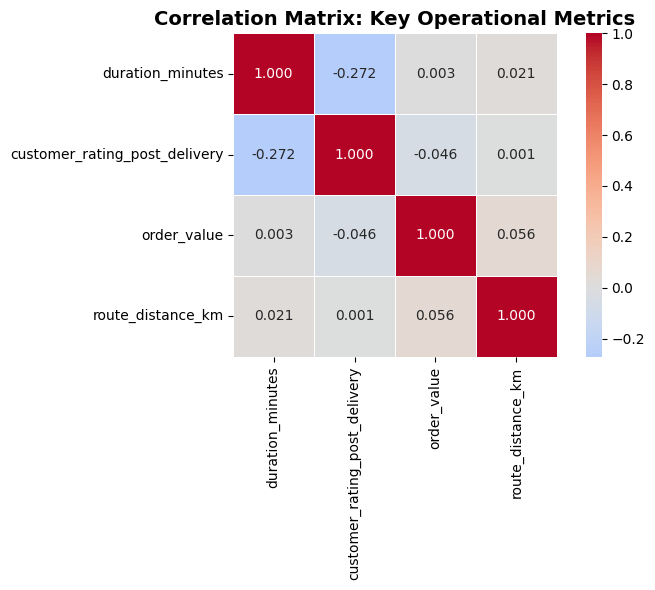


INTERPRETATION GUIDE
Values close to +1.0 = Strong positive relationship
Values close to -1.0 = Strong negative relationship
Values close to 0.0 = No linear relationship


In [ ]:
# ============================================
# CODE 6.3: Correlation Matrix and Heatmap
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

# Load orders data for merging
orders = pd.read_csv('DBA-Data-Analysis/orders.csv')

# Merge deliveries with orders to include order_value
merged = deliveries.merge(orders, on='order_id')

# Select numerical columns for correlation analysis
num_cols = ['duration_minutes', 'customer_rating_post_delivery',
            'order_value', 'route_distance_km']

# Filter to only columns that exist in the merged dataframe
existing_cols = [c for c in num_cols if c in merged.columns]

# Calculate correlation matrix
corr_matrix = merged[existing_cols].corr()

print("="*60)
print("CORRELATION MATRIX")
print("="*60)
print(corr_matrix.round(3))

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Key Operational Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print interpretation guidance
print("\n" + "="*60)
print("INTERPRETATION GUIDE")
print("="*60)
print("Values close to +1.0 = Strong positive relationship")
print("Values close to -1.0 = Strong negative relationship")
print("Values close to 0.0 = No linear relationship")

In [ ]:
# ============================================
# CODE 6.4: Descriptive Statistics Summary
# ============================================

# Select numerical columns for summary
numerical_cols = ['duration_minutes', 'customer_rating_post_delivery',
                  'route_distance_km', 'fuel_or_charge_cost']

# Generate descriptive statistics
summary_df = deliveries[numerical_cols].describe()

print("="*60)
print("DESCRIPTIVE STATISTICS SUMMARY")
print("="*60)
print(summary_df.round(2))

# percentage of missing data
print("\n" + "="*60)
print("DATA COMPLETENESS")
print("="*60)
for col in numerical_cols:
    missing_pct = (deliveries[col].isna().sum() / len(deliveries)) * 100
    print(f"{col}: {missing_pct:.1f}% missing")

DESCRIPTIVE STATISTICS SUMMARY
       duration_minutes  customer_rating_post_delivery  route_distance_km  \
count            931.00                         950.00             950.00   
mean             579.78                           3.81              13.91   
std              510.45                           1.00               7.48   
min                1.00                           0.00               1.20   
25%              176.00                           3.32               9.14   
50%              424.00                           4.03              12.84   
75%              878.50                           4.55              16.84   
max             2607.00                           5.00              41.94   

       fuel_or_charge_cost  
count               950.00  
mean                 12.84  
std                   4.34  
min                   2.50  
25%                   9.93  
50%                  12.64  
75%                  15.70  
max                  29.43  

DATA COMPLETE